# 02 - Exploratory Data Analysis
We explore the FPL past seasons dataset to understand distributions, correlations, and key patterns before modelling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/processed/player_past_seasons.csv')
print(df.shape)
df.head()

(2017, 37)


,season_name,element_code,start_cost,end_cost,total_points,minutes,goals_scored,assists,clean_sheets,goals_conceded,...,expected_goals,expected_assists,expected_goal_involvements,expected_goals_conceded,player_id,id,name,team,position,price
0,2021/22,154561,45,44,95,2160,0,0,8,27,...,0.00,0.00,0.00,0.00,1,1,Raya,Arsenal,GKP,6.0
1,2022/23,154561,45,48,166,3420,0,0,12,46,...,0.11,0.12,0.23,50.12,1,1,Raya,Arsenal,GKP,6.0
2,2023/24,154561,50,53,135,2880,0,0,16,24,...,0.00,0.04,0.04,22.51,1,1,Raya,Arsenal,GKP,6.0
3,2024/25,154561,55,56,142,3420,0,0,13,34,...,0.00,0.03,0.03,35.03,1,1,Raya,Arsenal,GKP,6.0
4,2025/26,154561,55,62,162,3330,0,0,19,26,...,0.00,0.07,0.07,27.56,1,1,Raya,Arsenal,GKP,6.0


In [2]:
# Basic info
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print('\nSeasons available:')
print(df['season_name'].value_counts())

season_name                         object
element_code                         int64
start_cost                           int64
end_cost                             int64
total_points                         int64
minutes                              int64
goals_scored                         int64
assists                              int64
clean_sheets                         int64
goals_conceded                       int64
own_goals                            int64
penalties_saved                      int64
penalties_missed                     int64
yellow_cards                         int64
red_cards                            int64
saves                                int64
bonus                                int64
bps                                  int64
influence                          float64
creativity                         float64
threat                             float64
ict_index                          float64
clearances_blocks_interceptions      int64
recoveries 

In [3]:
# Points distribution by position
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='position', y='total_points', order=['GKP','DEF','MID','FWD'], ax=axes[0])
axes[0].set_title('Total Points Distribution by Position')
axes[0].set_xlabel('Position')
axes[0].set_ylabel('Total Points')

sns.histplot(data=df, x='total_points', hue='position', bins=40, ax=axes[1], alpha=0.6)
axes[1].set_title('Points Distribution Histogram')
axes[1].set_xlabel('Total Points')

plt.tight_layout()
plt.savefig('../data/processed/points_by_position.png', dpi=150)
plt.show()

<Figure size 1400x500 with 2 Axes>

C:\Users\adity\AppData\Local\Temp\ipykernel_12072\2217647877.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_players, x='total_points', y='name', palette='viridis')


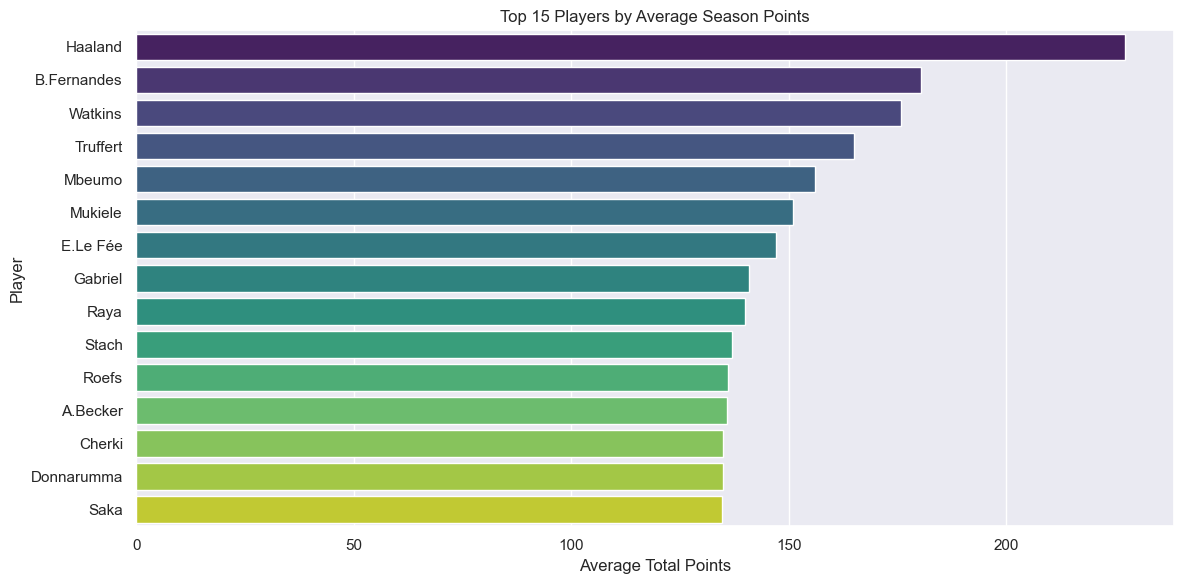

In [4]:
# Top 15 players by average points across seasons
top_players = (df.groupby('name')['total_points']
                 .mean()
                 .sort_values(ascending=False)
                 .head(15)
                 .reset_index())

plt.figure(figsize=(12, 6))
sns.barplot(data=top_players, x='total_points', y='name', palette='viridis')
plt.title('Top 15 Players by Average Season Points')
plt.xlabel('Average Total Points')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('../data/processed/top_players.png', dpi=150)
plt.show()

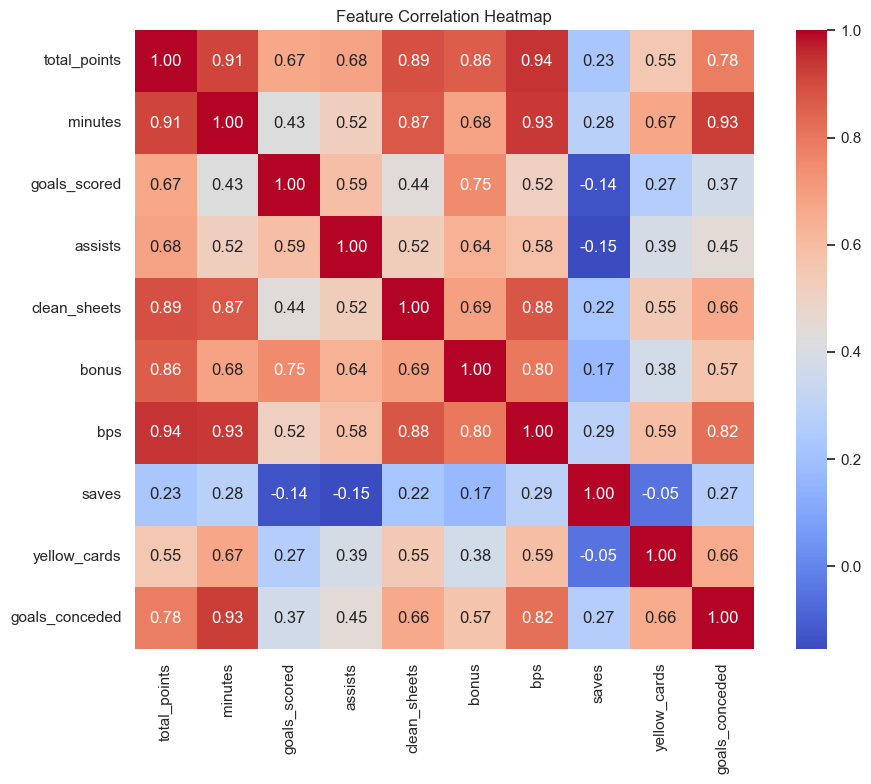

In [5]:
# Correlation heatmap of key features
num_cols = ['total_points', 'minutes', 'goals_scored', 'assists',
            'clean_sheets', 'bonus', 'bps', 'saves',
            'yellow_cards', 'goals_conceded']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

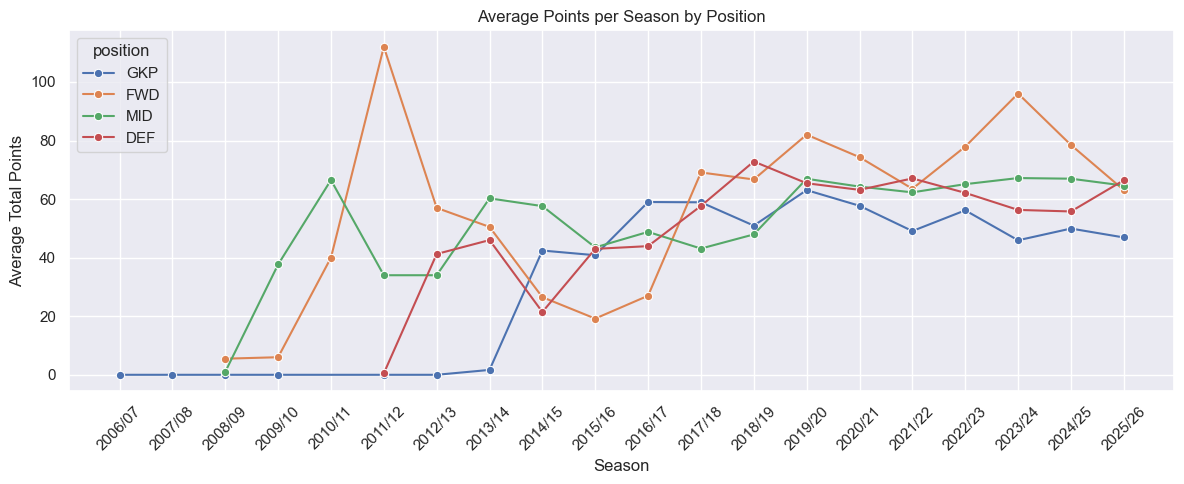

In [6]:
# Points trend across seasons
season_avg = df.groupby(['season_name', 'position'])['total_points'].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=season_avg, x='season_name', y='total_points', hue='position', marker='o')
plt.title('Average Points per Season by Position')
plt.xlabel('Season')
plt.ylabel('Average Total Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/processed/points_trend.png', dpi=150)
plt.show()

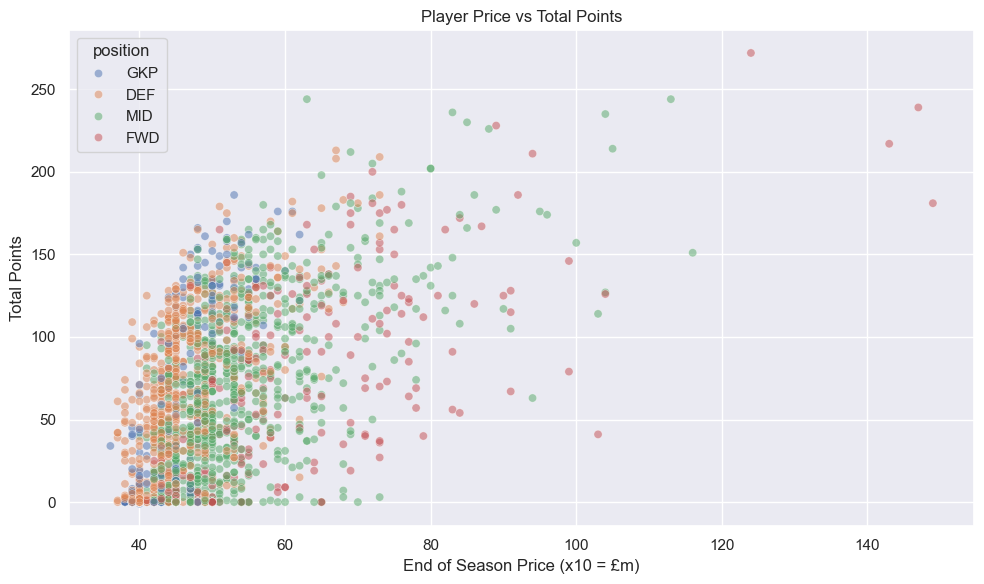

EDA complete. All plots saved.


In [7]:
# Price vs Points scatter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='end_cost', y='total_points', hue='position', alpha=0.5)
plt.title('Player Price vs Total Points')
plt.xlabel('End of Season Price (x10 = £m)')
plt.ylabel('Total Points')
plt.tight_layout()
plt.savefig('../data/processed/price_vs_points.png', dpi=150)
plt.show()

print('EDA complete. All plots saved.')